In [13]:
import pandas as pd

yalp_photos_json_path = "D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\photos.json"

photos_df = pd.read_json(yalp_photos_json_path, lines=True)

In [14]:
photos_df.head()

,photo_id,business_id,caption,label
0,zsvj7vloL4L5jhYyPIuVwg,Nk-SJhPlDBkAZvfsADtccA,Nice rock artwork everywhere and craploads of ...,inside
1,HCUdRJHHm_e0OCTlZetGLg,yVZtL5MmrpiivyCIrVkGgA,,outside
2,vkr8T0scuJmGVvN2HJelEA,_ab50qdWOk0DdB6XOrBitw,oyster shooter,drink
3,pve7D6NUrafHW3EAORubyw,SZU9c8V2GuREDN5KgyHFJw,Shrimp scampi,food
4,H52Er-uBg6rNrHcReWTD2w,Gzur0f0XMkrVxIwYJvOt2g,,food


In [15]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [17]:
# Check nulls and empty strings
null_photo_id = photos_df['photo_id'].isnull().sum()
empty_photo_id = (photos_df['photo_id'].astype(str).str.strip() == '').sum()

null_label = photos_df['label'].isnull().sum()
empty_label = (photos_df['label'].astype(str).str.strip() == '').sum()

print(f"Null photo_id: {null_photo_id}")
print(f"Empty photo_id: {empty_photo_id}")
print(f"Null label: {null_label}")
print(f"Empty label: {empty_label}")

Null photo_id: 0
Empty photo_id: 0
Null label: 0
Empty label: 0


In [19]:
# Count of businesses per label
label_counts_businesses = photos_df['label'].value_counts().sort_index()

print("Businesses per label:")
print(label_counts_businesses)

Businesses per label:
label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: count, dtype: int64


Businesses per label:
label
drink       15670
food       108152
inside      56031
menu         1678
outside     18569
Name: count, dtype: int64


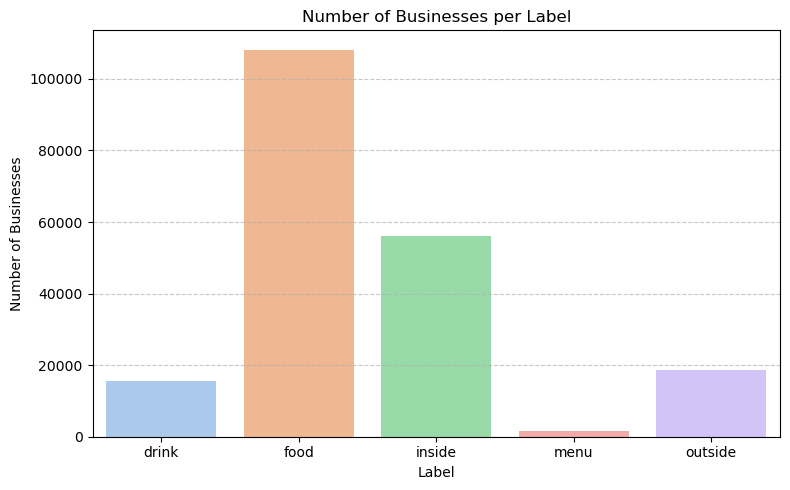

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count businesses per label
label_counts_businesses = photos_df['label'].value_counts().sort_index()

# Display counts
print("Businesses per label:")
print(label_counts_businesses)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts_businesses.index, y=label_counts_businesses.values, palette='pastel')

plt.title("Number of Businesses per Label")
plt.xlabel("Label")
plt.ylabel("Number of Businesses")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [27]:
base_image_countainer_folder_path = "D:\\loyalist\\sem3\\cnn\\Yelp-Photos\\yelp_photos\\photos\\"

In [28]:
import os
from PIL import Image
import pandas as pd
from tqdm import tqdm

# Enable progress_apply in pandas
tqdm.pandas()

# Define image root path
image_root = r"D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\photos"

# Function to check if image file exists and is not corrupt
def is_valid_image(photo_id):
    path = os.path.join(image_root, f"{photo_id}.jpg")
    if not os.path.exists(path):
        return False
    try:
        with Image.open(path) as img:
            img.verify()  # Verify does not load full image, just checks integrity
        return True
    except Exception:
        return False

In [30]:
# Assuming your DataFrame is called df_photos and has a column 'photo_id'
photos_df['is_valid'] = photos_df['photo_id'].progress_apply(is_valid_image)

100%|█████████████████████████████████████████████████████████████████████████| 200100/200100 [25:02<00:00, 133.15it/s]


In [34]:
total = len(photos_df)
valid = photos_df['is_valid'].sum()
invalid = total - valid
percent_valid = (valid / total) * 100

print(f"Total images: {total}")
print(f"✅ Valid images: {valid}")
print(f"❌ Invalid (missing/corrupt): {invalid}")
print(f"📊 Percentage valid: {percent_valid:.2f}%")

Total images: 200100
✅ Valid images: 199994
❌ Invalid (missing/corrupt): 106
📊 Percentage valid: 99.95%


In [35]:
photos_df_valid = photos_df[photos_df['is_valid']].copy()

In [37]:
photos_df_valid['label'].value_counts().sort_index()

label
drink       15670
food       108047
inside      56030
menu         1678
outside     18569
Name: count, dtype: int64

In [64]:
from sklearn.model_selection import train_test_split

# Pseudocode
#train_images = 90% of valid images
#eval_images  = 10% for FID / Inception Score
# Filter valid images first

train_df, fid_df = train_test_split(photos_df_valid, test_size=0.1, stratify=photos_df_valid['label'], random_state=42)

In [65]:
from PIL import Image

class ResizeWithPadding:
    def __init__(self, size, fill_color=(0, 0, 0)):
        self.size = size
        self.fill_color = fill_color

    def __call__(self, image):
        old_size = image.size  # (width, height)
        ratio = float(self.size) / max(old_size)
        new_size = tuple([int(x * ratio) for x in old_size])
        image = image.resize(new_size, Image.Resampling.LANCZOS)

        new_image = Image.new("RGB", (self.size, self.size), self.fill_color)
        paste_position = ((self.size - new_size[0]) // 2,
                          (self.size - new_size[1]) // 2)
        new_image.paste(image, paste_position)
        return new_image


In [66]:
from torchvision import transforms
import torchvision.transforms.functional as TF

# Apply resize with padding, then normalize
resize_transform = transforms.Compose([
    ResizeWithPadding(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Augmentation + Resize with padding
augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    ResizeWithPadding(64),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [83]:
import os
from tqdm import tqdm
from PIL import Image
import shutil
import torchvision 

#) Source path of raw images
image_root = r"D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\photos"
# Destination path for balanced dataset
output_root_segrigated = r"D:\loyalist\sem3\cnn\Yelp-Photos\train\segrigated_photos"
output_root_processed = r"D:\loyalist\sem3\cnn\Yelp-Photos\train\processed_photos"

# Ensure folders exist
os.makedirs(output_root_segrigated, exist_ok=True)
os.makedirs(output_root_processed, exist_ok=True)

# To store metadata of new dataset
balanced_records = []

# Target per label
TARGET = 5000

# Group images by label
grouped = train_df.groupby('label')

new_id_counter = 1

for label, group in grouped:
    print(f"📁 Processing label: {label} ({len(group)} images)")
    
    label_dir_segrigated = os.path.join(output_root_segrigated, label)
    os.makedirs(label_dir_segrigated, exist_ok=True)

    label_dir_processed = os.path.join(output_root_processed, label)
    os.makedirs(label_dir_processed, exist_ok=True)
    
    images_needed = TARGET
    used_ids = set()
    
    # Step 1: Copy real images (resized)
    for _, row in group.iterrows():
        if images_needed == 0:
            break
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        print(_, photo_id)
        
        try:
            img = Image.open(src_path).convert("RGB")
            img_resized = resize_transform(img)
            #Save original image
            segrigated_path = os.path.join(label_dir_segrigated, f"{photo_id}.jpg")
            img.save(segrigated_path)
            # Save resized image
            new_filename = f"{label}_{new_id_counter}_{photo_id}.jpg"
            processed_path = os.path.join(label_dir_processed, new_filename)
            torchvision.utils.save_image(img_resized, processed_path)
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': False
            })
            
            new_id_counter += 1
            images_needed -= 1
            used_ids.add(photo_id)
        except Exception as e:
            print(f"Skipping corrupt image: {photo_id}, error: {e}")
    
    # Step 2: Augment random images to fill remaining slots
    while images_needed > 0:
        row = group.sample(1).iloc[0]
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        print(3)
        try:
            img = Image.open(src_path).convert("RGB")
            img_aug = augment_transform(img)
            
            # Save augmented image
            new_filename = f"{label}_{new_id_counter}_aug.jpg"
            processed_path = os.path.join(label_dir_processed, new_filename)
            torchvision.utils.save_image(img_aug, processed_path)
            
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': True
            })
            
            new_id_counter += 1
            images_needed -= 1
        except Exception as e:
            print(f"Augment failed for {photo_id}, error: {e}")

df_balanced = pd.DataFrame(balanced_records)
df_balanced.to_csv(r"D:\loyalist\sem3\cnn\Yelp-Photos\train\processed_dataset_metadata.csv", index=False)

print("✅ Saved as CSV: balanced_dataset_metadata.csv")


📁 Processing label: drink (14103 images)
151783 1u4I3V3fhRDDfLHRbDwO9w
117100 kCob6wOKqwm6hXQ-WLYCOA
2745 0eDzm3uqdjvj1srynbO0uw
51376 tOATeq906QAXmmB8jWouNw
135259 Vc0E0fGqglH0Bj8fpfR29g
172393 X9do8pHK1H32R7h9pZrs8g
92317 ADUBBnXgvKJ4_-GZBkwmMg
133435 6b0iAoSKSspHWJ3Lz3ydGw
144909 1c0bbzL5biMdyA3mncHrqQ
73629 VayOHsS8roqZGb19__Xzrg
125727 dLAtVFOeCj-Zi_NYY_Rsng
103679 XDeah6H85-OzAdqDqwGF_g
20192 Cjfeiv_x_354NglG1Ruffg
96789 oJsMZFs3NRFKi50qG9jVFQ
5593 eVPObQiIWERtd4tmAZPMGQ
119390 Z-jDx7YhCVt0k1-7fQZD0A
167922 cWmE-Up8in_oHlDCkTCg3A
129882 oHXO-8_TcGvGTeu6U1UtfQ
51231 pG5xUBTqifwHj3NDO4Qelw
89583 RWySrydhSuNoOiZv0cuS-A
76802 JLc3CoyFwlJfvjkRtMUrqQ
84571 _I9ZBOetfaX7EWnu6pAI9w
129171 gaRULI4nbR5-XXhJrFNhfg
42894 tGV9_LHHbEbIl_nKyzagng
90474 GQxZTagoSAdKe5NhGDJdtA
73441 1mpmuu6RKqAfNyaEssLuOw
131189 nu3d9iA-qmW2XsCqOSwePQ
157793 KTTS-0KIK-8Yvqp5MMdAgg
8354 PSZbmA4PpYRTxQxE51mSfw
40949 CIQBRkQlZ3YY9DEbrn4brA
153540 zzgCrlfzTGj1lbckMMHB9g
154519 qL2frfKYph9TwGlQ18q7hw
155258 PmdSXI8kkoV

In [85]:
import os
from tqdm import tqdm
from PIL import Image
import shutil
import torchvision 

#) Source path of raw images
image_root = r"D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\photos"
# Destination path for balanced dataset
output_root_segrigated = r"D:\loyalist\sem3\cnn\Yelp-Photos\test\segrigated_photos"
output_root_processed = r"D:\loyalist\sem3\cnn\Yelp-Photos\test\processed_photos"

# Ensure folders exist
os.makedirs(output_root_segrigated, exist_ok=True)
os.makedirs(output_root_processed, exist_ok=True)

# To store metadata of new dataset
balanced_records = []

# Target per label
TARGET = 1000

# Group images by label
grouped = fid_df.groupby('label')

new_id_counter = 1

for label, group in grouped:
    print(f"📁 Processing label: {label} ({len(group)} images)")
    
    label_dir_segrigated = os.path.join(output_root_segrigated, label)
    os.makedirs(label_dir_segrigated, exist_ok=True)

    label_dir_processed = os.path.join(output_root_processed, label)
    os.makedirs(label_dir_processed, exist_ok=True)
    
    images_needed = TARGET
    used_ids = set()
    
    # Step 1: Copy real images (resized)
    for _, row in group.iterrows():
        if images_needed == 0:
            break
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        print(_, photo_id)
        
        try:
            img = Image.open(src_path).convert("RGB")
            img_resized = resize_transform(img)
            #Save original image
            segrigated_path = os.path.join(label_dir_segrigated, f"{photo_id}.jpg")
            img.save(segrigated_path)
            # Save resized image
            new_filename = f"{label}_{new_id_counter}_{photo_id}.jpg"
            processed_path = os.path.join(label_dir_processed, new_filename)
            torchvision.utils.save_image(img_resized, processed_path)
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': False
            })
            
            new_id_counter += 1
            images_needed -= 1
            used_ids.add(photo_id)
        except Exception as e:
            print(f"Skipping corrupt image: {photo_id}, error: {e}")
    ""
    # Step 2: Augment random images to fill remaining slots
    while images_needed > 0:
        row = group.sample(1).iloc[0]
        photo_id = row['photo_id']
        src_path = os.path.join(image_root, f"{photo_id}.jpg")
        print(3)
        try:
            img = Image.open(src_path).convert("RGB")
            img_aug = augment_transform(img)
            
            # Save augmented image
            new_filename = f"{label}_{new_id_counter}_aug.jpg"
            processed_path = os.path.join(label_dir_processed, new_filename)
            torchvision.utils.save_image(img_aug, processed_path)
            
            balanced_records.append({
                'new_photo_id': new_filename.split('.')[0],
                'label': label,
                'original_photo_id': photo_id,
                'augmented': True
            })
            
            new_id_counter += 1
            images_needed -= 1
        except Exception as e:
            print(f"Augment failed for {photo_id}, error: {e}")

df_balanced = pd.DataFrame(balanced_records)
df_balanced.to_csv(r"D:\loyalist\sem3\cnn\Yelp-Photos\test\processed_dataset_metadata.csv", index=False)

print("✅ Saved as CSV: balanced_dataset_metadata.csv")


📁 Processing label: drink (1567 images)
33464 8VfJq1vTpMh6IMKhtbsqHg
124353 3LGq6soWgPCWeVqaJCqCnw
2363 YoIAYWkm-2Di1c46gyJUXQ
154160 NwjHP2DiGj3xhCd8PnYcgg
45167 1XR1orXOs9DcwWwbep9USw
71020 JaUThH4LI-zCeQAFNTWhNg
96977 CaAayOWoPPtztWBkKrJ81g
1523 G1OP58atWLOwmWq45lfYKg
195707 PMw-2oUgnqL4h7mkJ8FquA
131455 -h_3dSAZ_5QRSLWc5TXrCA
178698 1eLPS0pRV5Rl82gXuJLOmQ
153463 jxr5zWGdJw-RQEjuTo4OKw
56509 G151P_ncS3kgispJGLdKSQ
94112 rnBO6oz7xqskNg6bTw1jAQ
86809 4PZLX6Ql0LJ1zOHbXM6nJA
32216 WkAatserHLITJzSujZ_SRA
183679 alcLmhhf3SHkU1d-HcHkYg
106535 rf3NNH2GaaLoIqiWS7qTRQ
9777 Ej9fNWpbwzuKJeaVqsgUyA
141765 9wTk1j-bB5UN17uiOeO9KA
111041 HOBYKgBAAM2a8W9W4jqjow
155341 6_vw5DuFIL-w2Qtnr9qlWw
124272 Ztb4nbeQ0B1HkLqPwZu08w
27508 qS7pvlDlM2FqlEpN5oGVWA
140403 9d0kiwGWg40hAMJtjsgQug
31219 MOtGSLozjg8lr0Zju-KgrA
83429 Zd4rjYrPWixphu0_ktxvIg
11580 MDAmYtDVMy9VIvAOOElCLw
4845 ZD-USZCV4_q3iLGYyAHdGQ
43751 tJlHHhfH5P2ZMd3Cp15x8g
96962 G0ThEZL37GCIGiHvvOEL9A
174706 qrizcqVMk2L9TZclPPX__Q
71423 y30XLDaZmjAMufVc

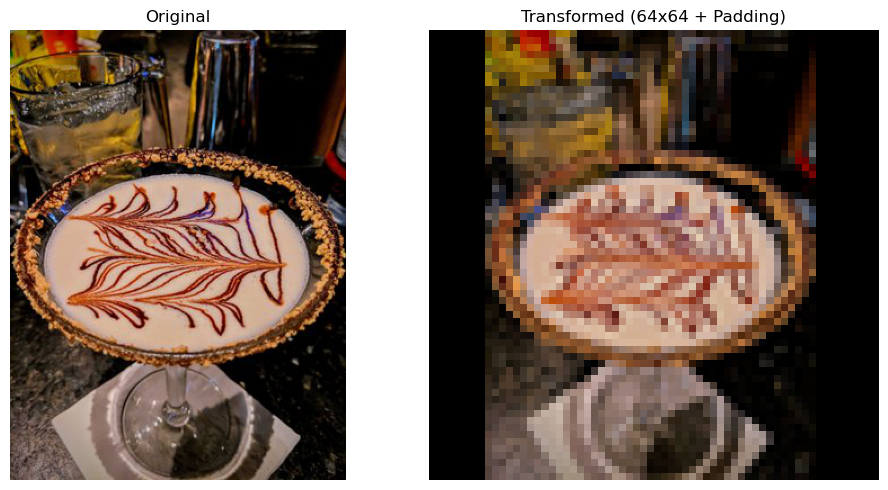

In [86]:
# Load an example image (change this to your path)
img_path = r"D:\loyalist\sem3\cnn\Yelp-Photos\yelp_photos\photos\__qwnab_ljzLZdiCbrkuTA.jpg"
original_img = Image.open(img_path).convert("RGB")

# Apply transform
transformed_tensor = resize_transform(original_img)

# Convert back to PIL for visualization (de-normalize first)
def denormalize(tensor):
    return tensor * 0.5 + 0.5  # Bring back to [0, 1] range

# Plot original vs transformed
plt.figure(figsize=(10, 5))

# Original
plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

# Transformed
plt.subplot(1, 2, 2)
transformed_img = denormalize(transformed_tensor).permute(1, 2, 0).clamp(0, 1)
plt.imshow(transformed_img)
plt.title("Transformed (64x64 + Padding)")
plt.axis("off")

plt.tight_layout()
plt.show()
